In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
import os, torch, platform
print("cwd:", os.getcwd())
print("machine:", platform.node())
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

cwd: /content
machine: 35d9d0ba06d0
cuda: True
gpu: Tesla T4


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
data = data.to(device)
target = target.to(device)

NameError: name 'model' is not defined

In [20]:
!rm -rf hoankiem-air-quality-forecasting

In [4]:
%cd /content

!rm -rf hoankiem-air-quality-forecasting

!git clone https://github.com/HoangHumg1210/hoankiem-air-quality-forecasting.git

%cd hoankiem-air-quality-forecasting

!ls

/content
Cloning into 'hoankiem-air-quality-forecasting'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 86 (delta 37), reused 68 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 8.60 MiB | 21.48 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/hoankiem-air-quality-forecasting
data  notebooks  requirements.txt  src


In [ ]:
# import os, sys

# PROJECT_ROOT = "/content/hoankiem-air-quality"  # thư mục chứa folder src/
# assert os.path.isdir(PROJECT_ROOT), f"Không thấy thư mục: {PROJECT_ROOT}"

# if PROJECT_ROOT not in sys.path:
#     sys.path.insert(0, PROJECT_ROOT)  # ưu tiên path này

In [5]:
import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# from fix_data_leakage import scale_data_without_leakage, create_sequences
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline




In [6]:
from src.data_utils import (
    set_seed,
    load_and_clean_data,
    add_time_features,
    add_target_features,
    split_data,
    transform_target,
    preprocess_features,
    create_sequences
)

In [7]:
TARGET = 'PM25'
LOOKBACK = 336
HORIZON = 72
USE_LOG_TARGET = True
DATA_PATH = 'data/processed/data2225_done.csv'


In [8]:
def prepare_sequences_for_experiment(
    data_path: str,
    target: str = "PM25",
    transform: str = "log",  # "log" / "sqrt" / "none"
    lookback: int = 336,
    horizon: int = 72,
):
    """Chuẩn bị X_seq, y_seq cho 1 cấu hình thí nghiệm.

    Hàm này lặp lại đúng pipeline trong `src.data_utils` nhưng cho phép
    thay đổi transform target và tham số LOOKBACK / HORIZON.
    """
    df = load_and_clean_data(data_path)
    df = add_time_features(df)
    df = add_target_features(df, target=target)

    train_df, val_df, test_df = split_data(df)

    # 1) Transform target theo config
    y_train, y_val, y_test, scaler_y, inverse_target_transform = transform_target(
        train_df,
        val_df,
        test_df,
        target=target,
        transform=transform,
    )

    # 2) Preprocess features
    X_train, X_val, X_test, preprocess = preprocess_features(
        train_df,
        val_df,
        test_df,
        target=target,
    )

    # 3) Tạo sequence
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback=lookback, horizon=horizon)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, lookback=lookback, horizon=horizon)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, lookback=lookback, horizon=horizon)

    return {
        "df": df,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "X_train_seq": X_train_seq,
        "y_train_seq": y_train_seq,
        "X_val_seq": X_val_seq,
        "y_val_seq": y_val_seq,
        "X_test_seq": X_test_seq,
        "y_test_seq": y_test_seq,
        "scaler_y": scaler_y,
        "inverse_target_transform": inverse_target_transform,
        "preprocess": preprocess,
        "lookback": lookback,
        "horizon": horizon,
        "transform": transform,
    }


def build_cnn_gru_model(
    n_features: int,
    lookback: int,
    horizon: int,
    arch: str = "heavy"
):
    """Xây dựng kiến trúc CNN-GRU cho multi-step forecasting."""
    if arch == "heavy":
        model = Sequential([
            Conv1D(
                filters=64,
                kernel_size=3,
                activation="relu",
                padding="same",
                input_shape=(lookback, n_features)
            ),
            Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
            MaxPooling1D(pool_size=2),
            Dropout(0.2),

            GRU(256, return_sequences=True),
            Dropout(0.2),
            GRU(128, return_sequences=True),
            Dropout(0.2),
            GRU(64, return_sequences=False),
            Dropout(0.2),

            Dense(32, activation="relu"),
            Dense(horizon),
        ])

    elif arch == "light":
        model = Sequential([
            GRU(128, return_sequences=True, input_shape=(lookback, n_features)),
            Dropout(0.1),
            GRU(64, return_sequences=False),
            Dropout(0.1),
            Dense(32, activation="relu"),
            Dense(horizon),
        ])
    else:
        raise ValueError(f"Unknown arch type: {arch}")

    return model

In [9]:
prepare_sequences_for_experiment(
    data_path=DATA_PATH,
    target=TARGET,
    transform="none",
    lookback=LOOKBACK,
    horizon=HORIZON,
)


{'df':                         CO    NO2    O3    PM10   PM25    SO2  Clouds  \
 Local Time                                                              
 2022-01-16 07:00:00  342.6  19.00  48.0  117.00  20.54  33.00    75.0   
 2022-01-16 08:00:00  297.6  15.00  60.7   97.70  17.16  26.30    75.0   
 2022-01-16 09:00:00  252.7  11.00  73.3   78.30  13.78  19.70    75.0   
 2022-01-16 10:00:00  207.8   7.00  86.0   59.00  10.40  13.00    75.0   
 2022-01-16 11:00:00  192.4   5.70  90.0   55.30   9.73  12.00    70.0   
 ...                    ...    ...   ...     ...    ...    ...     ...   
 2025-12-31 19:00:00  195.5  16.80  83.0   55.20  54.60  51.60    68.0   
 2025-12-31 20:00:00  183.8  15.18  80.3   52.98  49.40  49.02    73.0   
 2025-12-31 21:00:00  172.2  13.62  77.7   50.82  44.20  46.38    84.0   
 2025-12-31 22:00:00  160.5  12.00  75.0   48.60  39.00  43.80    87.0   
 2025-12-31 23:00:00  162.4  11.82  69.3   48.60  41.20  41.82    90.0   
 
                      Precipit


Running experiment: A_no_log_MSE_h72_l336_cnn_gru_heavy
Config: {'name': 'A_no_log_MSE_h72_l336_cnn_gru_heavy', 'transform': 'log', 'lookback': 336, 'horizon': 72, 'loss': 'mse', 'arch': 'heavy'}
X_train_seq shape: (16746, 336, 43)
y_train_seq shape: (16746, 72)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 1.7489 - mae: 0.6597 - val_loss: 0.8282 - val_mae: 0.7332 - learning_rate: 0.0010
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.9950 - mae: 0.4935 - val_loss: 0.9359 - val_mae: 0.7751 - learning_rate: 0.0010
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.8396 - mae: 0.4502 - val_loss: 1.0946 - val_mae: 0.8362 - learning_rate: 0.0010
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6847 - mae: 0.4080 - val_loss: 1.0655 - val_mae: 0.8111 - learning_rate: 0.0010
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.5938 - mae: 0.3787 - val_loss: 1.2845 - val_mae: 0.8899 - learning_rate: 0.0010
Epoch 6/100
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5611 - mae: 0.3640
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.5610 - mae: 0.3640 - val_loss: 1.0579 - val_mae: 0.8149 - learn

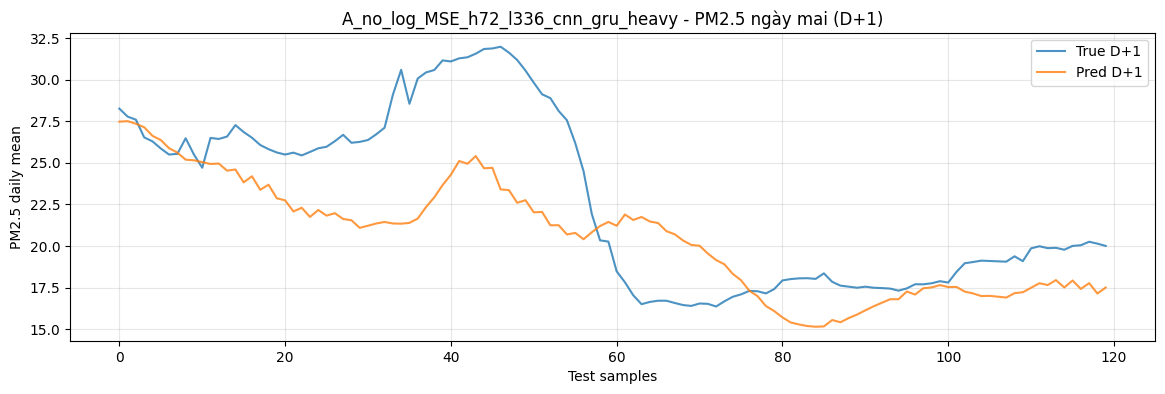

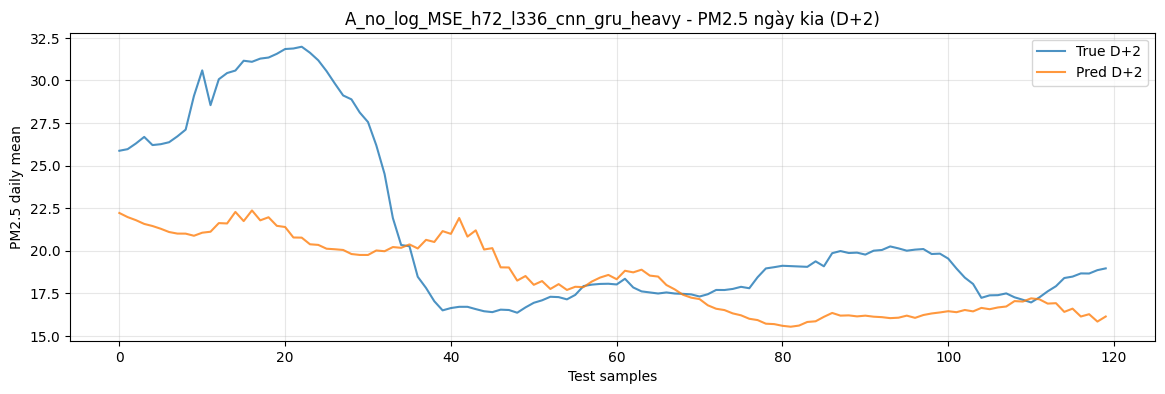

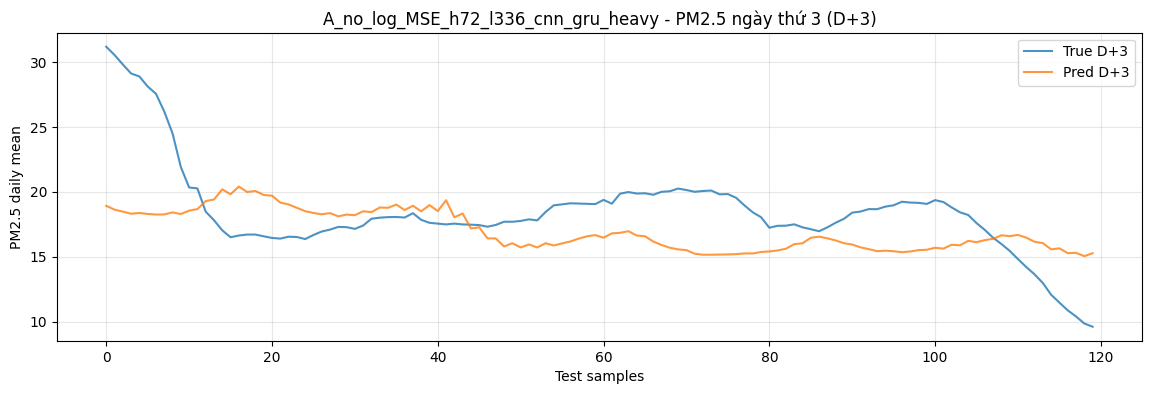


=== Tóm tắt kết quả các cấu hình ===
A_no_log_MSE_h72_l336_cnn_gru_heavy: transform=log, loss=mse, lookback=336, horizon=72 | MAE(D+1/D+2/D+3/All)=(9.7355, 10.1943, 10.7553, 10.2284) | RMSE(D+1/D+2/D+3/All)=(13.0593, 13.7892, 14.8074, 13.9038)


In [12]:
experiment_configs = [
    {
        "name": "A_no_log_MSE_h72_l336_cnn_gru_heavy",
        "transform": "log",
        "lookback": 336,
        "horizon": 72,   # 72 giờ = 3 ngày
        "loss": "mse",
        "arch": "heavy",
    }
]

results_summary = []


def inverse_scale_2d(arr_2d, scaler):
    original_shape = arr_2d.shape
    return scaler.inverse_transform(arr_2d.reshape(-1, 1)).reshape(original_shape)


def aggregate_72h_to_3days(arr_2d):
    """
    arr_2d: shape (N, 72)
    return: shape (N, 3)
    """
    day1 = arr_2d[:, 0:24].mean(axis=1)
    day2 = arr_2d[:, 24:48].mean(axis=1)
    day3 = arr_2d[:, 48:72].mean(axis=1)
    return np.stack([day1, day2, day3], axis=1)


for cfg in experiment_configs:
    print("\n" + "=" * 80)
    print(f"Running experiment: {cfg['name']}")
    print("Config:", cfg)

    artifacts = prepare_sequences_for_experiment(
        data_path=DATA_PATH,
        target=TARGET,
        transform=cfg["transform"],
        lookback=cfg["lookback"],
        horizon=cfg["horizon"],
    )

    X_train_seq = artifacts["X_train_seq"]
    y_train_seq = artifacts["y_train_seq"]
    X_val_seq = artifacts["X_val_seq"]
    y_val_seq = artifacts["y_val_seq"]
    X_test_seq = artifacts["X_test_seq"]
    y_test_seq = artifacts["y_test_seq"]
    scaler_y = artifacts["scaler_y"]
    inverse_target_transform = artifacts["inverse_target_transform"]

    print("X_train_seq shape:", X_train_seq.shape)
    print("y_train_seq shape:", y_train_seq.shape)

    if len(X_train_seq) == 0 or len(X_val_seq) == 0:
        print("WARNING: empty sequences for this config, skip.")
        continue

    n_features = X_train_seq.shape[2]
    lookback = cfg["lookback"]
    horizon = cfg["horizon"]

    model = build_cnn_gru_model(
        n_features=n_features,
        lookback=lookback,
        horizon=horizon,
        arch=cfg["arch"],
    )

    loss_name = cfg["loss"].lower()
    if loss_name == "mse":
        loss_fn = tf.keras.losses.MeanSquaredError()
    elif loss_name == "mae":
        loss_fn = tf.keras.losses.MeanAbsoluteError()
    else:
        raise ValueError(f"Unsupported loss in this cell: {loss_name}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=loss_fn,
        metrics=["mae"],
    )

    # 1 weight / sample
    thr = np.quantile(y_train_seq, 0.90)
    w_train = np.where((y_train_seq > thr).any(axis=1), 4.0, 1.0).astype(np.float32)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    )

    history = model.fit(
        X_train_seq,
        y_train_seq,
        sample_weight=w_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop, lr_scheduler],
        verbose=1,
    )

    # Predict 72 giờ
    y_pred_scaled = model.predict(X_test_seq)

    # inverse scaling
    y_pred_t = inverse_scale_2d(y_pred_scaled, scaler_y)
    y_test_t_inv = inverse_scale_2d(y_test_seq, scaler_y)

    # inverse target transform
    y_pred_raw = inverse_target_transform(y_pred_t)
    y_test_raw_inv = inverse_target_transform(y_test_t_inv)

    # gộp 72 giờ -> 3 ngày
    y_pred_3d = aggregate_72h_to_3days(y_pred_raw)
    y_true_3d = aggregate_72h_to_3days(y_test_raw_inv)

    # Metric từng ngày
    mae_day1 = mean_absolute_error(y_true_3d[:, 0], y_pred_3d[:, 0])
    mae_day2 = mean_absolute_error(y_true_3d[:, 1], y_pred_3d[:, 1])
    mae_day3 = mean_absolute_error(y_true_3d[:, 2], y_pred_3d[:, 2])

    rmse_day1 = math.sqrt(mean_squared_error(y_true_3d[:, 0], y_pred_3d[:, 0]))
    rmse_day2 = math.sqrt(mean_squared_error(y_true_3d[:, 1], y_pred_3d[:, 1]))
    rmse_day3 = math.sqrt(mean_squared_error(y_true_3d[:, 2], y_pred_3d[:, 2]))

    # Metric gộp cả 3 ngày
    mae_all = mean_absolute_error(y_true_3d.reshape(-1), y_pred_3d.reshape(-1))
    rmse_all = math.sqrt(mean_squared_error(y_true_3d.reshape(-1), y_pred_3d.reshape(-1)))

    print(f"{cfg['name']} - MAE D+1:  {mae_day1:.4f}")
    print(f"{cfg['name']} - MAE D+2:  {mae_day2:.4f}")
    print(f"{cfg['name']} - MAE D+3:  {mae_day3:.4f}")
    print(f"{cfg['name']} - MAE All:  {mae_all:.4f}")

    print(f"{cfg['name']} - RMSE D+1: {rmse_day1:.4f}")
    print(f"{cfg['name']} - RMSE D+2: {rmse_day2:.4f}")
    print(f"{cfg['name']} - RMSE D+3: {rmse_day3:.4f}")
    print(f"{cfg['name']} - RMSE All: {rmse_all:.4f}")

    results_summary.append(
        {
            "name": cfg["name"],
            "transform": cfg["transform"],
            "lookback": cfg["lookback"],
            "horizon": cfg["horizon"],
            "loss": cfg["loss"],
            "arch": cfg["arch"],
            "mae_day1": float(mae_day1),
            "mae_day2": float(mae_day2),
            "mae_day3": float(mae_day3),
            "mae_all": float(mae_all),
            "rmse_day1": float(rmse_day1),
            "rmse_day2": float(rmse_day2),
            "rmse_day3": float(rmse_day3),
            "rmse_all": float(rmse_all),
        }
    )

    # Plot D+1
    plt.figure(figsize=(14, 4))
    n_plot = min(120, len(y_true_3d))
    plt.plot(y_true_3d[:n_plot, 0], label="True D+1", alpha=0.8)
    plt.plot(y_pred_3d[:n_plot, 0], label="Pred D+1", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 ngày mai (D+1)")
    plt.xlabel("Test samples")
    plt.ylabel("PM2.5 daily mean")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Plot D+2
    plt.figure(figsize=(14, 4))
    plt.plot(y_true_3d[:n_plot, 1], label="True D+2", alpha=0.8)
    plt.plot(y_pred_3d[:n_plot, 1], label="Pred D+2", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 ngày kia (D+2)")
    plt.xlabel("Test samples")
    plt.ylabel("PM2.5 daily mean")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Plot D+3
    plt.figure(figsize=(14, 4))
    plt.plot(y_true_3d[:n_plot, 2], label="True D+3", alpha=0.8)
    plt.plot(y_pred_3d[:n_plot, 2], label="Pred D+3", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 ngày thứ 3 (D+3)")
    plt.xlabel("Test samples")
    plt.ylabel("PM2.5 daily mean")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


print("\n=== Tóm tắt kết quả các cấu hình ===")
for r in results_summary:
    print(
        f"{r['name']}: transform={r['transform']}, loss={r['loss']}, "
        f"lookback={r['lookback']}, horizon={r['horizon']} | "
        f"MAE(D+1/D+2/D+3/All)=({r['mae_day1']:.4f}, {r['mae_day2']:.4f}, {r['mae_day3']:.4f}, {r['mae_all']:.4f}) | "
        f"RMSE(D+1/D+2/D+3/All)=({r['rmse_day1']:.4f}, {r['rmse_day2']:.4f}, {r['rmse_day3']:.4f}, {r['rmse_all']:.4f})"
    )


Running experiment: A_no_log_MSE_h72_l336_cnn_gru_heavy
Config: {'name': 'A_no_log_MSE_h72_l336_cnn_gru_heavy', 'transform': 'none', 'lookback': 336, 'horizon': 72, 'loss': 'mse', 'arch': 'heavy'}
X_train_seq shape: (16746, 336, 43)
y_train_seq shape: (16746, 72)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 2.2452 - mae: 0.5495 - val_loss: 1.6813 - val_mae: 0.9439 - learning_rate: 0.0010
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 1.4000 - mae: 0.4173 - val_loss: 1.2132 - val_mae: 0.8379 - learning_rate: 0.0010
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 1.1855 - mae: 0.3794 - val_loss: 1.6142 - val_mae: 0.9723 - learning_rate: 0.0010
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 0.9598 - mae: 0.3451 - val_loss: 1.6686 - val_mae: 0.9630 - learning_rate: 0.0010
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.8654 - mae: 0.3258 - val_loss: 1.2111 - val_mae: 0.8067 - learning_rate: 0.0010
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 0.8184 - mae: 0.3142 - val_loss: 1.5923 - val_mae: 0.9407 - learning_rate: 0.0010
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.7671 - mae: 0.3040 - val_loss: 1.7594 - val_mae: 0.9820 - learnin

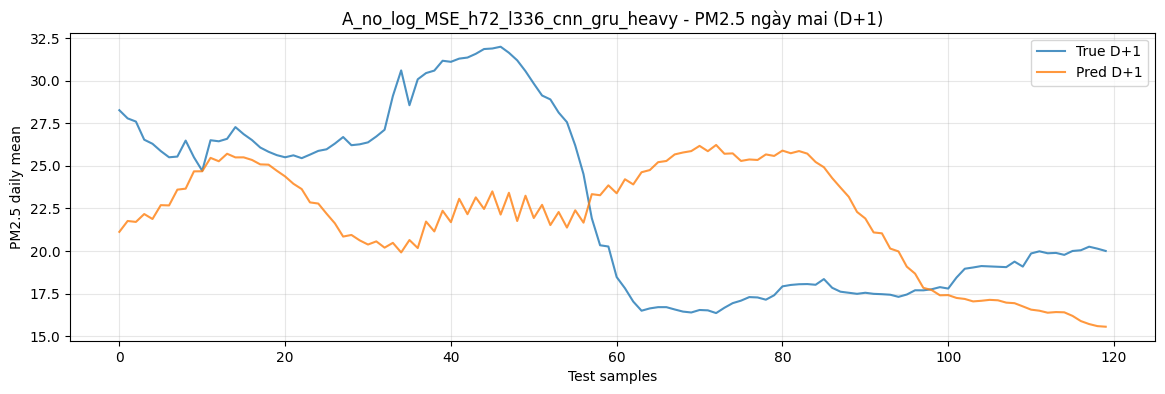

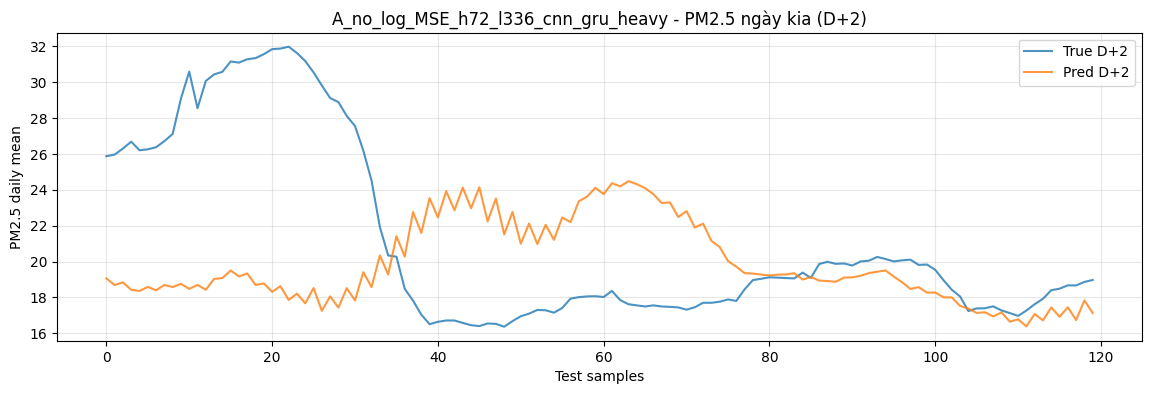

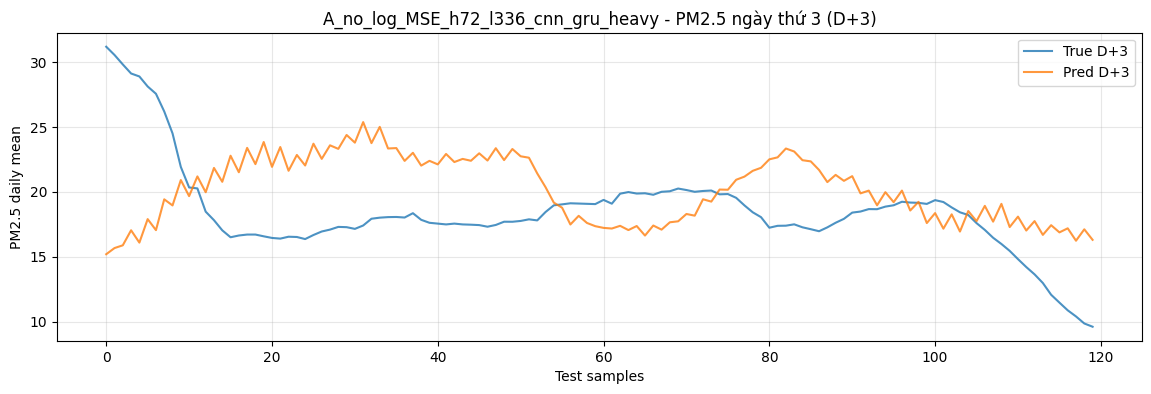


=== Tóm tắt kết quả các cấu hình ===
A_no_log_MSE_h72_l336_cnn_gru_heavy: transform=none, loss=mse, lookback=336, horizon=72 | MAE(D+1/D+2/D+3/All)=(10.4273, 11.7969, 12.1679, 11.4640) | RMSE(D+1/D+2/D+3/All)=(13.9064, 15.7452, 16.3465, 15.3678)


In [14]:
experiment_configs = [
    {
        "name": "A_no_log_MSE_h72_l336_cnn_gru_heavy",
        "transform": "none",
        "lookback": 336,
        "horizon": 72,   # 72 giờ = 3 ngày
        "loss": "mse",
        "arch": "heavy",
    }
]

results_summary = []


def inverse_scale_2d(arr_2d, scaler):
    original_shape = arr_2d.shape
    return scaler.inverse_transform(arr_2d.reshape(-1, 1)).reshape(original_shape)


def aggregate_72h_to_3days(arr_2d):
    """
    arr_2d: shape (N, 72)
    return: shape (N, 3)
    """
    day1 = arr_2d[:, 0:24].mean(axis=1)
    day2 = arr_2d[:, 24:48].mean(axis=1)
    day3 = arr_2d[:, 48:72].mean(axis=1)
    return np.stack([day1, day2, day3], axis=1)


for cfg in experiment_configs:
    print("\n" + "=" * 80)
    print(f"Running experiment: {cfg['name']}")
    print("Config:", cfg)

    artifacts = prepare_sequences_for_experiment(
        data_path=DATA_PATH,
        target=TARGET,
        transform=cfg["transform"],
        lookback=cfg["lookback"],
        horizon=cfg["horizon"],
    )

    X_train_seq = artifacts["X_train_seq"]
    y_train_seq = artifacts["y_train_seq"]
    X_val_seq = artifacts["X_val_seq"]
    y_val_seq = artifacts["y_val_seq"]
    X_test_seq = artifacts["X_test_seq"]
    y_test_seq = artifacts["y_test_seq"]
    scaler_y = artifacts["scaler_y"]
    inverse_target_transform = artifacts["inverse_target_transform"]

    print("X_train_seq shape:", X_train_seq.shape)
    print("y_train_seq shape:", y_train_seq.shape)

    if len(X_train_seq) == 0 or len(X_val_seq) == 0:
        print("WARNING: empty sequences for this config, skip.")
        continue

    n_features = X_train_seq.shape[2]
    lookback = cfg["lookback"]
    horizon = cfg["horizon"]

    model = build_cnn_gru_model(
        n_features=n_features,
        lookback=lookback,
        horizon=horizon,
        arch=cfg["arch"],
    )

    loss_name = cfg["loss"].lower()
    if loss_name == "mse":
        loss_fn = tf.keras.losses.MeanSquaredError()
    elif loss_name == "mae":
        loss_fn = tf.keras.losses.MeanAbsoluteError()
    else:
        raise ValueError(f"Unsupported loss in this cell: {loss_name}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=loss_fn,
        metrics=["mae"],
    )

    # 1 weight / sample
    thr = np.quantile(y_train_seq, 0.90)
    w_train = np.where((y_train_seq > thr).any(axis=1), 4.0, 1.0).astype(np.float32)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    )

    history = model.fit(
        X_train_seq,
        y_train_seq,
        sample_weight=w_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop, lr_scheduler],
        verbose=1,
    )

    # Predict 72 giờ
    y_pred_scaled = model.predict(X_test_seq)

    # inverse scaling
    y_pred_t = inverse_scale_2d(y_pred_scaled, scaler_y)
    y_test_t_inv = inverse_scale_2d(y_test_seq, scaler_y)

    # inverse target transform
    y_pred_raw = inverse_target_transform(y_pred_t)
    y_test_raw_inv = inverse_target_transform(y_test_t_inv)

    # gộp 72 giờ -> 3 ngày
    y_pred_3d = aggregate_72h_to_3days(y_pred_raw)
    y_true_3d = aggregate_72h_to_3days(y_test_raw_inv)

    # Metric từng ngày
    mae_day1 = mean_absolute_error(y_true_3d[:, 0], y_pred_3d[:, 0])
    mae_day2 = mean_absolute_error(y_true_3d[:, 1], y_pred_3d[:, 1])
    mae_day3 = mean_absolute_error(y_true_3d[:, 2], y_pred_3d[:, 2])

    rmse_day1 = math.sqrt(mean_squared_error(y_true_3d[:, 0], y_pred_3d[:, 0]))
    rmse_day2 = math.sqrt(mean_squared_error(y_true_3d[:, 1], y_pred_3d[:, 1]))
    rmse_day3 = math.sqrt(mean_squared_error(y_true_3d[:, 2], y_pred_3d[:, 2]))

    # Metric gộp cả 3 ngày
    mae_all = mean_absolute_error(y_true_3d.reshape(-1), y_pred_3d.reshape(-1))
    rmse_all = math.sqrt(mean_squared_error(y_true_3d.reshape(-1), y_pred_3d.reshape(-1)))

    print(f"{cfg['name']} - MAE D+1:  {mae_day1:.4f}")
    print(f"{cfg['name']} - MAE D+2:  {mae_day2:.4f}")
    print(f"{cfg['name']} - MAE D+3:  {mae_day3:.4f}")
    print(f"{cfg['name']} - MAE All:  {mae_all:.4f}")

    print(f"{cfg['name']} - RMSE D+1: {rmse_day1:.4f}")
    print(f"{cfg['name']} - RMSE D+2: {rmse_day2:.4f}")
    print(f"{cfg['name']} - RMSE D+3: {rmse_day3:.4f}")
    print(f"{cfg['name']} - RMSE All: {rmse_all:.4f}")

    results_summary.append(
        {
            "name": cfg["name"],
            "transform": cfg["transform"],
            "lookback": cfg["lookback"],
            "horizon": cfg["horizon"],
            "loss": cfg["loss"],
            "arch": cfg["arch"],
            "mae_day1": float(mae_day1),
            "mae_day2": float(mae_day2),
            "mae_day3": float(mae_day3),
            "mae_all": float(mae_all),
            "rmse_day1": float(rmse_day1),
            "rmse_day2": float(rmse_day2),
            "rmse_day3": float(rmse_day3),
            "rmse_all": float(rmse_all),
        }
    )

    # Plot D+1
    plt.figure(figsize=(14, 4))
    n_plot = min(120, len(y_true_3d))
    plt.plot(y_true_3d[:n_plot, 0], label="True D+1", alpha=0.8)
    plt.plot(y_pred_3d[:n_plot, 0], label="Pred D+1", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 ngày mai (D+1)")
    plt.xlabel("Test samples")
    plt.ylabel("PM2.5 daily mean")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Plot D+2
    plt.figure(figsize=(14, 4))
    plt.plot(y_true_3d[:n_plot, 1], label="True D+2", alpha=0.8)
    plt.plot(y_pred_3d[:n_plot, 1], label="Pred D+2", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 ngày kia (D+2)")
    plt.xlabel("Test samples")
    plt.ylabel("PM2.5 daily mean")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Plot D+3
    plt.figure(figsize=(14, 4))
    plt.plot(y_true_3d[:n_plot, 2], label="True D+3", alpha=0.8)
    plt.plot(y_pred_3d[:n_plot, 2], label="Pred D+3", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 ngày thứ 3 (D+3)")
    plt.xlabel("Test samples")
    plt.ylabel("PM2.5 daily mean")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


print("\n=== Tóm tắt kết quả các cấu hình ===")
for r in results_summary:
    print(
        f"{r['name']}: transform={r['transform']}, loss={r['loss']}, "
        f"lookback={r['lookback']}, horizon={r['horizon']} | "
        f"MAE(D+1/D+2/D+3/All)=({r['mae_day1']:.4f}, {r['mae_day2']:.4f}, {r['mae_day3']:.4f}, {r['mae_all']:.4f}) | "
        f"RMSE(D+1/D+2/D+3/All)=({r['rmse_day1']:.4f}, {r['rmse_day2']:.4f}, {r['rmse_day3']:.4f}, {r['rmse_all']:.4f})"
    )

In [13]:
!nvidia-smi

Tue Mar 17 02:40:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             29W /   70W |    2183MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# === Experiments: target transform + loss + horizon/lookback + architecture ===

experiment_configs = [
    {
        "name": "A_no_log_MSE_h8_l336_cnn_gru_heavy",
        "transform": "none",
        "lookback": 168,
        "horizon": 3,
        "loss": "mse",
        "arch": "heavy",
    },
    {
        "name": "B_log_MAE_h8_l336_cnn_gru_heavy",
        "transform": "log",
        "lookback": 336,
        "horizon": 8,
        "loss": "mae",
        "arch": "heavy",
    },
    {
        "name": "C_no_log_MSE_h1_l168_cnn_gru_light",
        "transform": "none",
        "lookback": 168,
        "horizon": 1,
        "loss": "mse",
        "arch": "light",
    },
]

results_summary = []

for cfg in experiment_configs:
    print("\n" + "=" * 80)
    print(f"Running experiment: {cfg['name']}")
    print("Config:", cfg)

    # 1) Chuẩn bị dữ liệu & sequence cho cấu hình này
    artifacts = prepare_sequences_for_experiment(
        data_path=DATA_PATH,
        target=TARGET,
        transform=cfg["transform"],
        lookback=cfg["lookback"],
        horizon=cfg["horizon"],
    )

    X_train_seq = artifacts["X_train_seq"]
    y_train_seq = artifacts["y_train_seq"]
    X_val_seq = artifacts["X_val_seq"]
    y_val_seq = artifacts["y_val_seq"]
    X_test_seq = artifacts["X_test_seq"]
    y_test_seq = artifacts["y_test_seq"]
    scaler_y = artifacts["scaler_y"]
    inverse_target_transform = artifacts["inverse_target_transform"]

    if len(X_train_seq) == 0 or len(X_val_seq) == 0:
        print("WARNING: empty sequences for this config, skip.")
        continue

    n_features = X_train_seq.shape[2]
    lookback = cfg["lookback"]

    # 2) Xây dựng model
    model = build_cnn_gru_model(n_features=n_features, lookback=lookback, arch=cfg["arch"])

    # 3) Chọn loss function
    loss_name = cfg["loss"].lower()
    if loss_name == "mse":
        loss_fn = tf.keras.losses.MeanSquaredError()
    elif loss_name == "mae":
        loss_fn = tf.keras.losses.MeanAbsoluteError()
    else:
        raise ValueError(f"Unsupported loss in this cell: {loss_name}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=loss_fn,
        metrics=["mae"],
    )

    # 4) Tăng trọng số cho các điểm y_train_seq cao (trong không gian đã transform + scale)
    thr = np.quantile(y_train_seq, 0.90)
    w_train = np.where(y_train_seq > thr, 4.0, 1.0).astype(np.float32)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    )
    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    )

    history = model.fit(
        X_train_seq,
        y_train_seq,
        sample_weight=w_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop, lr_scheduler],
        verbose=1,
    )

    # 5) Dự báo trên test và tính MAE / RMSE trong đơn vị PM2.5 gốc
    y_pred_scaled = model.predict(X_test_seq)
    y_pred_t = scaler_y.inverse_transform(y_pred_scaled)
    y_test_t_inv = scaler_y.inverse_transform(y_test_seq)

    y_pred_raw = inverse_target_transform(y_pred_t)
    y_test_raw_inv = inverse_target_transform(y_test_t_inv)

    mae_val = mean_absolute_error(y_test_raw_inv, y_pred_raw)
    rmse_val = math.sqrt(mean_squared_error(y_test_raw_inv, y_pred_raw))

    print(f"{cfg['name']} - MAE:  {mae_val:.4f}")
    print(f"{cfg['name']} - RMSE: {rmse_val:.4f}")

    # Lưu lại để so sánh sau
    results_summary.append(
        {
            "name": cfg["name"],
            "transform": cfg["transform"],
            "lookback": cfg["lookback"],
            "horizon": cfg["horizon"],
            "loss": cfg["loss"],
            "arch": cfg["arch"],
            "mae": float(mae_val),
            "rmse": float(rmse_val),
        }
    )

    # 6) Vẽ nhanh đồ thị so sánh y_true vs y_pred trên 1 đoạn test
    plt.figure(figsize=(14, 4))
    n_plot = min(500, len(y_test_raw_inv))
    plt.plot(y_test_raw_inv[:n_plot], label="True", alpha=0.8)
    plt.plot(y_pred_raw[:n_plot], label="Pred", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 thực tế vs dự báo (đoạn đầu test)")
    plt.xlabel("Time steps (test subset)")
    plt.ylabel("PM2.5")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


print("\n=== Tóm tắt kết quả các cấu hình ===")
for r in results_summary:
    print(
        f"{r['name']}: transform={r['transform']}, loss={r['loss']}, "
        f"lookback={r['lookback']}, horizon={r['horizon']} | "
        f"MAE={r['mae']:.4f}, RMSE={r['rmse']:.4f}"
    )
